# CET1-Ratio Constrained Reverse Stress Test (Lasso-restricted sensitivities)

**Variant**: Sector long-run sensitivities sum **OLS** coefficients only where `lasso_feature_selection_results.csv` has `β_selected_*` / `δ_selected_*` == 1 (from `01_pd_analysis/nbmacroDFandSensitivity.ipynb`). Shock vector $\boldsymbol{\Delta}$ is unchanged.

**Goal**: Find the *most plausible* macro-geopolitical deviation $\boldsymbol{\Delta}$ from the historical
mean that drives the **stressed CET1 ratio below a breakdown threshold** $R^\omega$.

Formally (Definition 2, Hurlin et al. 2026):

$$\min_{\boldsymbol{\Delta} \in \mathbb{R}^5} \; D_M^2 = \boldsymbol{\Delta}^\top \boldsymbol{\Sigma}^{-1} \boldsymbol{\Delta}$$

$$\text{subject to} \quad R(\boldsymbol{\Delta}) \leq R^\omega$$

where $R(\boldsymbol{\Delta}) = \frac{\text{CET1}^0 - L_q(\boldsymbol{\Delta})}{\text{RWA}(\boldsymbol{\Delta})}$ is the stressed CET1 ratio,
$R^\omega = R^0 \cdot (1 - \epsilon)$ is the breakdown threshold (ECB 2026: $\epsilon = 3\%$, i.e. 300 bps depletion).

---

### Methodology

**Step 1 — Macro $\to$ stressed PD** (long-run sensitivity model):

$$\text{PD}_i^*(\boldsymbol{\Delta}) = \sigma\!\left(\text{logit}(\text{PD}_i^0) + \mathbf{b}_{s(i)}^{\text{total}} \cdot \boldsymbol{\Delta}\right)$$

**Step 2 — Portfolio tail loss** (Gordy 2003, 99.9%):

$$L_q(\boldsymbol{\Delta}) = \sum_{i=1}^{n} \text{EAD}_i \cdot \text{LGD} \cdot \Phi\!\left(\frac{\Phi^{-1}(\text{PD}_i^*) + \sqrt{\rho_i}\,\Phi^{-1}(q)}{\sqrt{1-\rho_i}}\right)$$

**Step 3 — Stressed RWA** (Basel IRB formula, eq. 19–20 in Hurlin et al.):

$$\text{RWA}(\boldsymbol{\Delta}) = \sum_{i=1}^{n} \text{EAD}_i \cdot 12.5 \cdot K_i(\text{PD}_i^*)$$

**Step 4 — Stressed CET1 ratio** (eq. 22):

$$R(\boldsymbol{\Delta}) = \frac{\text{CET1}^0 - L_q(\boldsymbol{\Delta})}{\text{RWA}(\boldsymbol{\Delta})}$$

**Solver**: SLSQP (Sequential Least Squares Programming), scipy.optimize.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm, chi2
from scipy.optimize import minimize, approx_fprime
import sys
import pathlib
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(pathlib.Path.cwd().parent))
from pd_pipeline.basel import asset_correlation_formula, calculate_capital_requirement
from pd_pipeline import data, config

# ── Shared problem parameters ──────────────────────────────────────────────────
LGD           = 0.40
LOSS_QUANTILE = 0.999       # Gordy tail quantile
MATURITY      = 2.5         # effective maturity (years)
N_LAGS        = 4           # number of quarterly lags in the OLS

# ── CET1 and capital-structure assumptions ─────────────────────────────────────
# CET1_RATIO_0  : assumed bank-wide CET1 ratio at baseline
# EAD_CET1_RATIO: assumed leverage ratio  EAD_portfolio / CET1  = 10
# DEPLETION     : absolute CET1 ratio depletion for breakdown (300 bps = 3 pp)
CET1_RATIO_0   = 0.17        # 17% initial CET1 ratio
EAD_CET1_RATIO = 10.0        # EAD of corporate portfolio = 10 × CET1 capital
DEPLETION      = 0.03        # 300 bps absolute depletion (ECB 2026 benchmark)
R_OMEGA        = CET1_RATIO_0 - DEPLETION   # breakdown threshold = 14%

MACRO_VARS = ['GDP_Growth', 'Interest_Rate', 'Brent_Oil', 'Fuel_Index', 'CPI']
GPR_VARS   = ['GPR_Global']
ALL_VARS   = MACRO_VARS + GPR_VARS
N_VARS     = len(ALL_VARS)

VAR_LABELS = {
    'GDP_Growth'    : 'GDP Index',
    'Interest_Rate' : 'Interest Rate (%)',
    'Brent_Oil'     : 'Brent Oil (USD/bbl)',
    'Fuel_Index'    : 'Non-Fuel Commodity Index',
    'CPI'           : 'CPI Index',
    'GPR_Global'    : 'GPR Index',
}

print(f'LGD              = {LGD:.0%}')
print(f'Gordy quantile   = {LOSS_QUANTILE:.1%}')
print(f'Initial CET1     = {CET1_RATIO_0:.1%}')
print(f'EAD / CET1       = {EAD_CET1_RATIO:.0f}x  (portfolio leverage assumption)')
print(f'Depletion ε    = {DEPLETION:.0%}  ({int(DEPLETION*10000)} bps absolute)')
print(f'Threshold R_ω  = {R_OMEGA:.4%}')


LGD              = 40%
Gordy quantile   = 99.9%
Initial CET1     = 17.0%
EAD / CET1       = 10x  (portfolio leverage assumption)
Depletion ε    = 3%  (300 bps absolute)
Threshold R_ω  = 14.0000%


## Lasso feature inclusion by sector

Which contemporaneous and lagged predictors Lasso kept (non-zero) per sector, from `../01_pd_analysis/lasso_feature_selection_results.csv` (12-month PD horizon). `t` = current quarter; `L1`…`L4` = lags.


In [ ]:
df_lasso_report = pd.read_csv('../01_pd_analysis/lasso_feature_selection_results.csv')
df_lr = df_lasso_report[df_lasso_report['PD_Horizon'] == '12_month'].copy()


def _sel(row, col: str) -> bool:
    if col not in row.index:
        return False
    v = row[col]
    if pd.isna(v):
        return False
    return int(v) == 1


def _format_var_lags(row, v: str, *, gpr: bool):
    p = '\u03b4' if gpr else '\u03b2'
    tags = []
    if _sel(row, f'{p}_selected_{v}'):
        tags.append('t')
    for k in range(1, N_LAGS + 1):
        if _sel(row, f'{p}_selected_{v}_lag{k}'):
            tags.append(f'L{k}')
    if not tags:
        return None
    return f"{v} [{', '.join(tags)}]"


print('Lasso-selected predictors by sector (12-month horizon)\n')
for _, row in df_lr.sort_values('Sector').iterrows():
    sector = row['Sector']
    macro_bits = []
    for v in MACRO_VARS:
        s = _format_var_lags(row, v, gpr=False)
        if s is not None:
            macro_bits.append(s)
    gpr_bits = []
    for v in GPR_VARS:
        s = _format_var_lags(row, v, gpr=True)
        if s is not None:
            gpr_bits.append(s)
    n_sel = int(row['N_features_selected']) if 'N_features_selected' in row and pd.notna(row['N_features_selected']) else None
    print(f'--- {sector} ---')
    if n_sel is not None:
        print(f"  Lasso non-zero terms (count column): {n_sel}")
    if macro_bits:
        print('  Macro: ' + '; '.join(macro_bits))
    else:
        print('  Macro: (none)')
    if gpr_bits:
        print('  GPR:   ' + '; '.join(gpr_bits))
    else:
        print('  GPR:   (none)')
    print()


## 1. Portfolio Exposures

In [2]:
df_port = pd.read_csv('../data/portfolio_simulation.csv')
df_port['rho']        = df_port['pd'].apply(asset_correlation_formula)
df_port['pd_clipped'] = np.clip(df_port['pd'], 1e-9, 1 - 1e-9)

print(f'Exposures   : {len(df_port):,}')
print(f'Total EAD   : {df_port["ead_eur_m"].sum():,.1f} EUR million')
ead_w_pd = (df_port['pd'] * df_port['ead_eur_m']).sum() / df_port['ead_eur_m'].sum()
print(f'Average PD          : {df_port["pd"].mean()*100:.2f}%')
print(f'EAD-weighted PD     : {ead_w_pd*100:.2f}%')
print()
print(df_port['sector'].value_counts().rename('count').to_frame().to_string())

Exposures   : 1,000
Total EAD   : 49,700.7 EUR million
Average PD          : 2.98%
EAD-weighted PD     : 1.20%

                                      count
sector                                     
Finance, Insurance & Real Estate        271
Heavy Manufacturing                     143
Utilities                               120
Light Manufacturing                     112
Communications                          104
Mining & Construction                    74
Services                                 61
Wholesale & Retail Trade                 61
Transportation                           27
Health, Legal & Educational Services     19
Public Administration                     8


## 2. Long-Run Sensitivity Coefficients (Lasso-masked)

OLS estimates come from `sensitivity_results_with_CI.csv`. For each sector, include a contemporaneous or lagged OLS term only if the matching `β_selected_*` or `δ_selected_*` in `lasso_feature_selection_results.csv` (12-month horizon) equals 1. If a sector is missing from the Lasso file, all lags are included (same as the CET1 notebook).


In [ ]:
df_sens = pd.read_csv('../01_pd_analysis/sensitivity_results_with_CI.csv')
df_s12  = df_sens[df_sens['PD_Horizon'] == '12_month'].copy()

df_lasso = pd.read_csv('../01_pd_analysis/lasso_feature_selection_results.csv')
df_l12 = df_lasso[df_lasso['PD_Horizon'] == '12_month'].copy()
lasso_by_sector = df_l12.set_index('Sector')


def _full_long_run_sum(ols_row, v, *, gpr: bool) -> float:
    p = 'δ' if gpr else 'β'
    t = float(ols_row[f'{p}_{v}'])
    for k in range(1, N_LAGS + 1):
        t += float(ols_row.get(f'{p}_{v}_lag{k}', 0) or 0)
    return t


def lasso_masked_long_run(ols_row, lasso_row, v, *, gpr: bool) -> float:
    """Sum OLS coefficients; keep term only if Lasso selected it (flag == 1)."""
    p = 'δ' if gpr else 'β'

    def selected(suffix: str) -> bool:
        if lasso_row is None:
            return True
        col = f'{p}_selected_{suffix}'
        if col not in lasso_row.index:
            return True
        val = lasso_row[col]
        if pd.isna(val):
            return False
        return int(val) == 1

    total = 0.0
    if selected(v):
        total += float(ols_row[f'{p}_{v}'])
    for k in range(1, N_LAGS + 1):
        suf = f'{v}_lag{k}'
        if selected(suf):
            total += float(ols_row.get(f'{p}_{suf}', 0) or 0)
    return total


sens_total = {}
max_abs_diff = 0.0
for _, row in df_s12.iterrows():
    sector = row['Sector']
    lr = lasso_by_sector.loc[sector] if sector in lasso_by_sector.index else None
    if lr is not None and isinstance(lr, pd.DataFrame):
        lr = lr.iloc[0]
    betas = {}
    for v in MACRO_VARS:
        betas[v] = lasso_masked_long_run(row, lr, v, gpr=False)
        max_abs_diff = max(max_abs_diff, abs(betas[v] - _full_long_run_sum(row, v, gpr=False)))
    for v in GPR_VARS:
        betas[v] = lasso_masked_long_run(row, lr, v, gpr=True)
        max_abs_diff = max(max_abs_diff, abs(betas[v] - _full_long_run_sum(row, v, gpr=True)))
    sens_total[sector] = betas

tbl = pd.DataFrame(sens_total).T[ALL_VARS].rename(columns=VAR_LABELS)
print('Lasso-masked long-run sensitivity coefficients  [Δ logit-PD per unit of Δ macro var]')
print(tbl.round(4).to_string())
print()
print(f'Diagnostic: max |masked - full OLS long-run sum| = {max_abs_diff:.6g}')
if max_abs_diff == 0.0:
    print('  -> No difference vs full sum: wrong CSV, path, or Sector name mismatch.')


In [4]:
# Filter portfolio to sectors with sensitivities
df_valid = df_port[df_port['sector'].isin(sens_total)].copy().reset_index(drop=True)
print(f'Exposures matched to sensitivity sectors: {len(df_valid):,} / {len(df_port):,}')
ead_valid     = df_valid['ead_eur_m'].values
ead_w_pd_v    = float(np.sum(df_valid['pd_clipped'] * df_valid['ead_eur_m']) / df_valid['ead_eur_m'].sum())
print(f'Total EAD (matched) : {df_valid["ead_eur_m"].sum():,.1f} EUR million')
print(f'EAD-weighted PD     : {ead_w_pd_v*100:.2f}%')

n_exp = len(df_valid)
pd0   = df_valid['pd_clipped'].values
rho   = df_valid['rho'].values
ead   = df_valid['ead_eur_m'].values

# Build sensitivity matrix B_total : shape (n_exp, n_vars)
B_total = np.zeros((n_exp, N_VARS))
for i, (_, row) in enumerate(df_valid.iterrows()):
    s = row['sector']
    for j, v in enumerate(ALL_VARS):
        B_total[i, j] = sens_total[s][v]

# Pre-compute constants for the Gordy formula
sqrt_rho   = np.sqrt(rho)
sqrt_1mrho = np.sqrt(1 - rho)
inv_q      = norm.ppf(LOSS_QUANTILE)
logit_pd0  = np.log(pd0 / (1 - pd0))   # logit(PD_base)

Exposures matched to sensitivity sectors: 1,000 / 1,000
Total EAD (matched) : 49,700.7 EUR million
EAD-weighted PD     : 1.20%


## 3. Historical Distribution Parameters

In [5]:
macro_frames = data.load_macro_data(
    gdp_path      = '../data/macro/global_gdp_monthly.csv',
    interest_path = '../data/macro/intrest FRED.csv',
    brent_path    = '../data/macro/brent_oil_monthly.csv',
    fuel_path     = '../data/macro/fuel_index_monthly.csv',
    cpi_path      = '../data/macro/global_cpi_monthly.csv',
    verbose       = False,
)
df_gpr    = data.load_gpr_data('../data/geopolitical/data_gpr_Data_GPR.csv', verbose=False)
df_merged = data.merge_macro_data(macro_frames, df_gpr)

cov_df, _, mean_series = data.summarize_macro_data(
    df_merged, config.ALL_PREDICTOR_COLS, verbose=False
)

mu        = mean_series.values          # (6,)
Sigma     = cov_df.values               # (6×6)
Sigma_inv = np.linalg.inv(Sigma)
stds      = np.sqrt(np.diag(Sigma))

print('Historical mean vector μ  (= scenario baseline):')
for v, m, s in zip(ALL_VARS, mu, stds):
    print(f'  {v:30s}: μ = {m:>10.3f},  σ = {s:>8.3f}')

Historical mean vector μ  (= scenario baseline):
  GDP_Growth                    : μ =    110.933,  σ =   13.041
  Interest_Rate                 : μ =      1.523,  σ =    1.847
  Brent_Oil                     : μ =     75.520,  σ =   23.572
  Fuel_Index                    : μ =    127.424,  σ =   22.221
  CPI                           : μ =    109.165,  σ =   18.406
  GPR_Global                    : μ =    105.275,  σ =   33.978


## 4. Baseline Capital Metrics

We compute baseline RWA at $\boldsymbol{\Delta} = \mathbf{0}$ using the Basel IRB formula,
then derive $\text{CET1}^0 = R^0 \cdot \text{RWA}^0$.

In [6]:
# ── Step 1: Corporate portfolio RWA at baseline (\u0394 = 0) ───────────────────────
K_base     = calculate_capital_requirement(pd0, LGD, rho, maturity=MATURITY)
RWA_corp_0 = float(np.sum(ead * K_base * 12.5))
EAD_total  = float(np.sum(ead))

# ── Step 2: CET1 capital from EAD / CET1 = EAD_CET1_RATIO assumption ──────────
CET1_0 = EAD_total / EAD_CET1_RATIO

# ── Step 3: Total bank RWA from baseline CET1 ratio ───────────────────────────
RWA_total_0 = CET1_0 / CET1_RATIO_0

# ── Step 4: Non-corporate RWA — held constant under any stress scenario ────────
# Only corporate portfolio RWA responds to macro shocks; everything else is fixed.
RWA_other = RWA_total_0 - RWA_corp_0

print('\u2500' * 55)
print('Corporate portfolio')
print('\u2500' * 55)
print(f'  Total EAD              : {EAD_total:>10,.1f} EUR million')
print(f'  Corporate RWA (\u0394=0)   : {RWA_corp_0:>10,.1f} EUR million')
print()
print('\u2500' * 55)
print('Bank-wide capital structure (baseline)')
print('\u2500' * 55)
print(f'  CET1\u2070  = EAD / {EAD_CET1_RATIO:.0f}       : {CET1_0:>10,.1f} EUR million')
print(f'  Total RWA\u2070 = CET1\u2070 / {CET1_RATIO_0:.0%} : {RWA_total_0:>10,.1f} EUR million')
print(f'  Non-corporate RWA      : {RWA_other:>10,.1f} EUR million  (constant)')
print(f'  Corporate RWA          : {RWA_corp_0:>10,.1f} EUR million  (stress-sensitive)')
print(f'  Corporate RWA share    : {RWA_corp_0/RWA_total_0:.1%} of total RWA')
print()
print(f'  Baseline CET1 ratio    : {CET1_0/RWA_total_0:.4%}  (= {CET1_RATIO_0:.0%} by construction)')
print(f'  Breakdown threshold R_\u03c9: {R_OMEGA:.4%}  ({CET1_RATIO_0:.0%} \u2212 {int(DEPLETION*10000)} bps)')


───────────────────────────────────────────────────────
Corporate portfolio
───────────────────────────────────────────────────────
  Total EAD              :   49,700.7 EUR million
  Corporate RWA (Δ=0)   :   24,497.8 EUR million

───────────────────────────────────────────────────────
Bank-wide capital structure (baseline)
───────────────────────────────────────────────────────
  CET1⁰  = EAD / 10       :    4,970.1 EUR million
  Total RWA⁰ = CET1⁰ / 17% :   29,235.7 EUR million
  Non-corporate RWA      :    4,737.9 EUR million  (constant)
  Corporate RWA          :   24,497.8 EUR million  (stress-sensitive)
  Corporate RWA share    : 83.8% of total RWA

  Baseline CET1 ratio    : 17.0000%  (= 17% by construction)
  Breakdown threshold R_ω: 14.0000%  (17% − 300 bps)


## 5. Functions: Loss, RWA, CET1 Ratio

- `portfolio_loss` / `portfolio_loss_grad` — unchanged from notebook 04 (CET1 numerator)
- `stressed_rwa` — new: Basel IRB RWA with stressed PDs (CET1 denominator)
- `cet1_ratio` — new: eq. (22) of Hurlin et al.
- `cet1_constraint` / `cet1_constraint_grad` — new: constraint $R^\omega - R(\boldsymbol{\Delta}) \geq 0$

In [7]:
# ── Shared with notebook 04 ────────────────────────────────────────────────────

def portfolio_loss(delta: np.ndarray) -> float:
    """Gordy 99.9% portfolio loss (EUR million) under macro deviation \u0394 from \u03bc."""
    adj        = np.clip(B_total @ delta, -50, 50)
    logit_pd_s = logit_pd0 + adj
    pd_s       = 1 / (1 + np.exp(-logit_pd_s))
    pd_s       = np.clip(pd_s, 1e-9, 1 - 1e-9)
    inv_pd_s   = norm.ppf(pd_s)
    cond_pd    = norm.cdf((inv_pd_s + sqrt_rho * inv_q) / sqrt_1mrho)
    return float(np.sum(ead * LGD * cond_pd))


def portfolio_loss_grad(delta: np.ndarray) -> np.ndarray:
    """Analytical gradient of portfolio_loss w.r.t. delta."""
    adj     = np.clip(B_total @ delta, -50, 50)
    pd_s    = np.clip(1 / (1 + np.exp(-(logit_pd0 + adj))), 1e-9, 1 - 1e-9)
    inv_pds = norm.ppf(pd_s)
    a       = (inv_pds + sqrt_rho * inv_q) / sqrt_1mrho
    phi_a   = norm.pdf(a)
    phi_inv = norm.pdf(inv_pds)
    var_pd  = pd_s * (1 - pd_s)
    return B_total.T @ (ead * LGD * phi_a * var_pd / (sqrt_1mrho * phi_inv))


def mahal_sq(delta: np.ndarray) -> float:
    """Squared Mahalanobis distance of \u0394."""
    return float(delta @ Sigma_inv @ delta)


def mahal_sq_grad(delta: np.ndarray) -> np.ndarray:
    """Analytical gradient of the squared Mahalanobis distance."""
    return 2 * Sigma_inv @ delta


# ── New: CET1-ratio functions ──────────────────────────────────────────────────

def stressed_rwa(delta: np.ndarray) -> float:
    """Total bank RWA under scenario \u0394.

    RWA_total(\u0394) = RWA_other  +  RWA_corp(\u0394)

    Non-corporate RWA (RWA_other) is held constant; only the corporate
    portfolio RWA responds to stressed PDs.  Eq. (20).
    """
    adj      = np.clip(B_total @ delta, -50, 50)
    pd_s     = np.clip(1 / (1 + np.exp(-(logit_pd0 + adj))), 1e-9, 1 - 1e-9)
    K_s      = calculate_capital_requirement(pd_s, LGD, rho, maturity=MATURITY)
    rwa_corp = float(np.sum(ead * K_s * 12.5))
    return RWA_other + rwa_corp


def cet1_ratio(delta: np.ndarray) -> float:
    """Stressed CET1 ratio: corporate losses deplete CET1, total bank RWA changes.

    R(\u0394) = (CET1_0 - \u0394L(\u0394)) / RWA_total(\u0394)

    where  \u0394L(\u0394)       = L_q(\u0394) - L_base         (incremental corporate loss)
    and    RWA_total(\u0394) = RWA_other + RWA_corp(\u0394)  (non-corporate is constant)

    R(\u0394=0) = CET1_0 / RWA_total_0 = CET1_RATIO_0 exactly.  Eq. (22).
    """
    incr_loss = portfolio_loss(delta) - loss_base
    return (CET1_0 - incr_loss) / stressed_rwa(delta)


def cet1_constraint(delta: np.ndarray) -> float:
    """R_\u03c9 - R(\u0394) \u2265 0  \u2194  ratio falls below threshold.  Eq. (23)."""
    return R_OMEGA - cet1_ratio(delta)


def cet1_constraint_grad(delta: np.ndarray) -> np.ndarray:
    """Numerical gradient of the CET1 constraint via forward differences."""
    return approx_fprime(delta, cet1_constraint, 1e-6)


# ── Baseline metrics (loss_base must be defined before cet1_ratio is called) ──
loss_base = portfolio_loss(np.zeros(N_VARS))
rwa_base  = stressed_rwa(np.zeros(N_VARS))
r0_check  = cet1_ratio(np.zeros(N_VARS))   # should equal CET1_RATIO_0 exactly

print(f'Baseline portfolio loss (\u0394=0, q=99.9%) : {loss_base:>10,.1f} EUR million')
print(f'Baseline RWA  (\u0394=0)                    : {rwa_base:>10,.1f} EUR million')
print(f'Baseline CET1 ratio  R\u2070                : {r0_check:.4%}  (should equal {CET1_RATIO_0:.2%})')
print(f'Breakdown threshold  R_\u03c9                : {R_OMEGA:.4%}  (baseline - threshold = {(r0_check - R_OMEGA)*10000:.0f} bps)')

Baseline portfolio loss (Δ=0, q=99.9%) :    1,725.1 EUR million
Baseline RWA  (Δ=0)                    :   29,235.7 EUR million
Baseline CET1 ratio  R⁰                : 17.0000%  (should equal 17.00%)
Breakdown threshold  R_ω                : 14.0000%  (baseline - threshold = 300 bps)


## 6. CET1 Ratio — Single-Factor Sensitivity

Each panel shows how the CET1 ratio responds to a ±3σ shift in one macro variable
while all others remain at their historical mean.

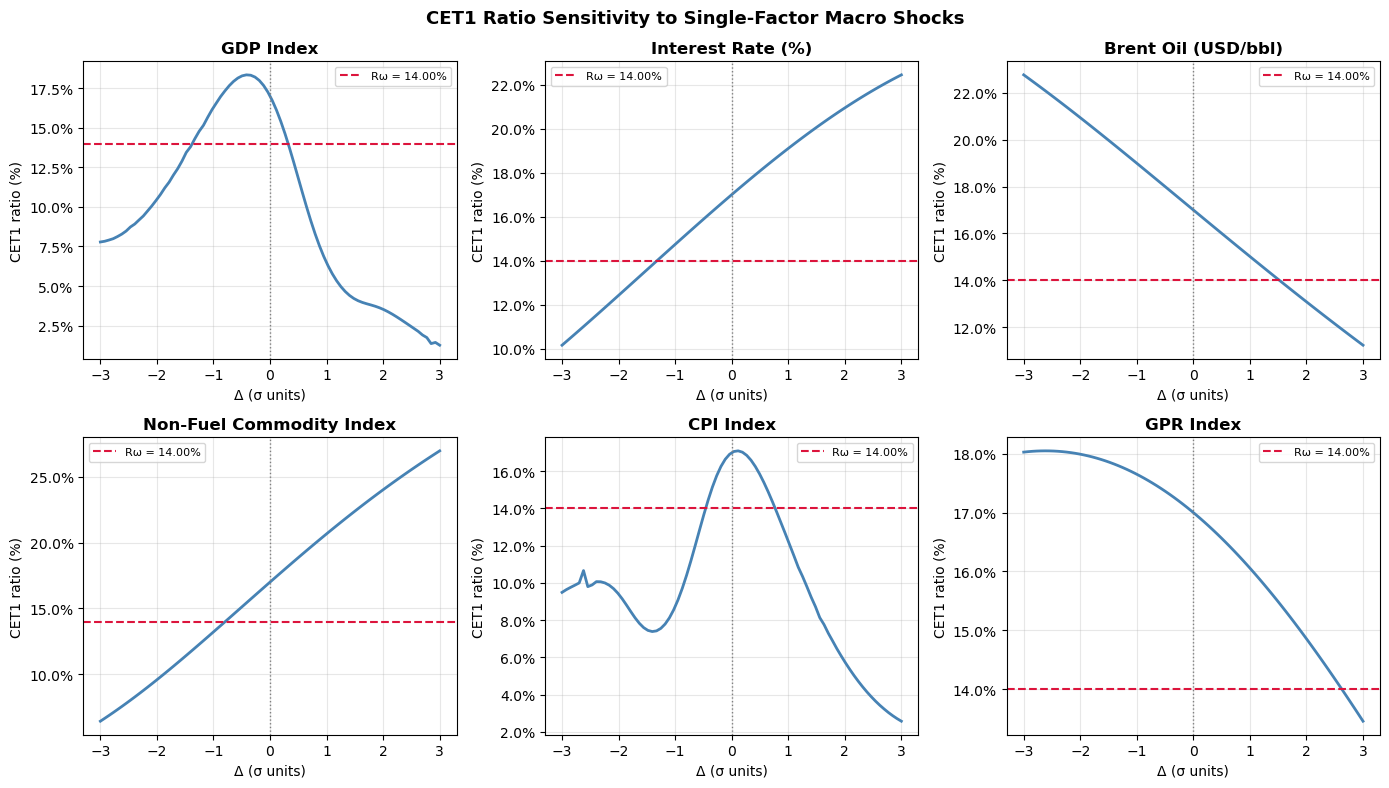

Chart saved → cet1_sensitivity.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

for idx, var in enumerate(ALL_VARS):
    ax  = axes_flat[idx]
    j   = ALL_VARS.index(var)
    std = stds[j]

    sweep   = np.linspace(-3 * std, 3 * std, 80)
    ratios  = []
    for dev in sweep:
        delta_test      = np.zeros(N_VARS)
        delta_test[j]   = dev
        ratios.append(cet1_ratio(delta_test) * 100)

    ax.plot(sweep / std, ratios, color='steelblue', lw=2)
    ax.axhline(R_OMEGA * 100, color='crimson', ls='--', lw=1.5,
               label=f'R\u03c9 = {R_OMEGA:.2%}')
    ax.axvline(0, color='grey', ls=':', lw=1)
    ax.set_title(VAR_LABELS[var], fontweight='bold')
    ax.set_xlabel('\u0394 (\u03c3 units)')
    ax.set_ylabel('CET1 ratio (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('CET1 Ratio Sensitivity to Single-Factor Macro Shocks',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('opt_lasso_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved \u2192 opt_lasso_sensitivity.png')

## 7. Constrained Optimisation

We minimise the **squared Mahalanobis distance** subject to the CET1 ratio falling
below the breakdown threshold $R^\omega$.
Multiple starting points are used for robustness.

In [9]:
constraint = {
    'type': 'ineq',
    'fun' : cet1_constraint,
    'jac' : cet1_constraint_grad,
}

rng6 = np.random.default_rng(42)
delta0_list = [
    np.zeros(N_VARS),
    np.array([-1.5, +1.0, +2.0, +0.5, +0.5, +1.0]) * stds,
    np.array([-1.0, +2.0, +2.5, +1.5, +0.5, +0.5]) * stds,
    np.array([-2.0, +0.5, +1.5, +1.0, +1.0, +2.0]) * stds,
    np.array([-0.5, +1.5, +3.0, +2.0, +0.5, +0.5]) * stds,
    np.array([-2.5, +2.0, +1.0, +0.5, +1.0, +1.5]) * stds,
    *(rng6.uniform(-3, 3, (5, N_VARS)) * stds),
]

best = None
for k, d0 in enumerate(delta0_list):
    res = minimize(
        mahal_sq,
        d0,
        method      = 'SLSQP',
        jac         = mahal_sq_grad,
        constraints = constraint,
        options     = dict(maxiter=3000, ftol=1e-12),
    )
    R    = cet1_ratio(res.x)
    D    = np.sqrt(mahal_sq(res.x))
    ok   = R <= R_OMEGA + 1e-4
    print(f'Run {k+1:2d}: success={res.success}, feasible={ok}, '
          f'D_M={D:.4f},  CET1={R:.4%}')
    if ok and (best is None or res.fun < best.fun):
        best = res

assert best is not None, 'No feasible solution found — try wider starting points'
delta_opt = best.x
D_opt     = np.sqrt(mahal_sq(delta_opt))
R_opt     = cet1_ratio(delta_opt)
L_opt     = portfolio_loss(delta_opt)
RWA_opt   = stressed_rwa(delta_opt)
x_opt     = mu + delta_opt

print(f'\n✓ Optimal Δ*:  D_M = {D_opt:.4f},  CET1 = {R_opt:.4%},  Loss = {L_opt:,.1f} EUR m')

Run  1: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run  2: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run  3: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run  4: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run  5: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run  6: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run  7: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run  8: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run  9: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run 10: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%
Run 11: success=True, feasible=True, D_M=1.7663,  CET1=14.0000%

✓ Optimal Δ*:  D_M = 1.7663,  CET1 = 14.0000%,  Loss = 2,051.9 EUR m


## 8. Optimal Scenario — Results Table

In [10]:
deviations_sigma = delta_opt / stds

results_df = pd.DataFrame({
    'Variable'          : ALL_VARS,
    'Label'             : [VAR_LABELS[v] for v in ALL_VARS],
    'Hist. mean \u03bc'      : mu,
    'Optimal x* = \u03bc+\u0394*' : x_opt,
    '\u0394* (raw)'          : delta_opt,
    '\u0394* / \u03c3'            : deviations_sigma,
})

print('=' * 90)
print(f'OPTIMAL MACRO SCENARIO  \u2014  most plausible scenario with CET1 \u2264 {R_OMEGA:.2%}')
print('=' * 90)
print(results_df.to_string(index=False, float_format=lambda v: f'{v:>10.3f}'))

p_chi2 = chi2.cdf(D_opt**2, df=N_VARS)
p_excl = 1 - p_chi2

print()
print(f'Mahalanobis distance D_M*          = {D_opt:.4f}')
print(f'Squared D_M*  (= \u03c7\u00b2 statistic)    = {D_opt**2:.4f}')
print(f'\u03c7\u00b2({N_VARS}) tail probability        = {p_excl:.4f}  '
      f'(under MVN, {p_excl*100:.2f}% of macro draws are at least this extreme)')
print()
print(f'Baseline CET1 ratio  R\u2070             = {CET1_RATIO_0:.4%}')
print(f'Stressed CET1 ratio  R(\u0394*)          = {R_opt:.4%}')
print(f'CET1 depletion                     = {(CET1_RATIO_0 - R_opt)*10000:.1f} bps')
print(f'Breakdown threshold  R_\u03c9            = {R_OMEGA:.4%}')
print()
print(f'Portfolio loss at \u0394*   (optimum)    = {L_opt:>10,.1f} EUR million')
print(f'Portfolio loss at \u0394=0  (baseline)   = {loss_base:>10,.1f} EUR million')
print(f'Stressed RWA  at \u0394*                 = {RWA_opt:>10,.1f} EUR million')
print(f'Baseline RWA  at \u0394=0                = {RWA_total_0:>10,.1f} EUR million')

OPTIMAL MACRO SCENARIO  —  most plausible scenario with CET1 ≤ 14.00%
     Variable                    Label  Hist. mean μ  Optimal x* = μ+Δ*   Δ* (raw)     Δ* / σ
   GDP_Growth                GDP Index       110.933            121.517     10.584      0.812
Interest_Rate        Interest Rate (%)         1.523              2.365      0.842      0.456
    Brent_Oil      Brent Oil (USD/bbl)        75.520             85.266      9.746      0.413
   Fuel_Index Non-Fuel Commodity Index       127.424            140.092     12.668      0.570
          CPI                CPI Index       109.165            123.059     13.894      0.755
   GPR_Global                GPR Index       105.275            150.258     44.983      1.324

Mahalanobis distance D_M*          = 1.7663
Squared D_M*  (= χ² statistic)    = 3.1197
χ²(6) tail probability        = 0.7937  (under MVN, 79.37% of macro draws are at least this extreme)

Baseline CET1 ratio  R⁰             = 17.0000%
Stressed CET1 ratio  R(Δ*)         

## 9. Stressed PDs and Capital at the Optimal Scenario

In [11]:
adj_opt     = np.clip(B_total @ delta_opt, -50, 50)
pd_stressed = 1 / (1 + np.exp(-(logit_pd0 + adj_opt)))
pd_stressed = np.clip(pd_stressed, 1e-9, 1 - 1e-9)
K_stressed  = calculate_capital_requirement(pd_stressed, LGD, rho, maturity=MATURITY)

df_valid = df_valid.copy()
df_valid['pd_base']     = pd0
df_valid['pd_stressed'] = pd_stressed
df_valid['pd_mult']     = pd_stressed / pd0
df_valid['K_base']      = K_base
df_valid['K_stressed']  = K_stressed
df_valid['rwa_base']    = ead * K_base * 12.5
df_valid['rwa_stressed']= ead * K_stressed * 12.5

tbl_pd = (
    df_valid.groupby('sector')
    .agg(
        n              = ('pd_base', 'count'),
        pd_base_pct    = ('pd_base',     lambda x: f"{x.mean()*100:.2f}%"),
        pd_stress_pct  = ('pd_stressed', lambda x: f"{x.mean()*100:.2f}%"),
        stress_mult    = ('pd_mult',     lambda x: f"{x.mean():.2f}\u00d7"),
        rwa_base_m     = ('rwa_base',    lambda x: f"{x.sum():,.0f}"),
        rwa_stress_m   = ('rwa_stressed',lambda x: f"{x.sum():,.0f}"),
    )
)
print('Sector breakdown at optimal \u0394* (EUR million for RWA):')
print(tbl_pd.to_string())
print()
print(f'Portfolio-wide base PD    : {pd0.mean()*100:.2f}%')
print(f'Portfolio-wide stressed PD: {pd_stressed.mean()*100:.2f}%')
print(f'Average stress multiplier : {(pd_stressed / pd0).mean():.2f}\u00d7')
print(f'Total base RWA            : {df_valid["rwa_base"].sum():,.1f} EUR million')
print(f'Total stressed RWA        : {df_valid["rwa_stressed"].sum():,.1f} EUR million')

Sector breakdown at optimal Δ* (EUR million for RWA):
                                        n pd_base_pct pd_stress_pct stress_mult rwa_base_m rwa_stress_m
sector                                                                                                 
Communications                        104       1.94%         3.77%       2.32×      2,835        4,362
Finance, Insurance & Real Estate      271       2.30%         3.11%       1.53×      7,279        9,149
Health, Legal & Educational Services   19       3.16%         3.22%       1.02×        184          187
Heavy Manufacturing                   143       3.48%         3.25%       0.92×      3,290        3,157
Light Manufacturing                   112       4.01%         4.25%       1.07×      1,756        1,817
Mining & Construction                  74       3.02%         3.93%       1.37×      1,946        2,299
Public Administration                   8       3.89%         4.05%       1.05×        155          159
Services  

## 10. Visualisation — Optimal Scenario

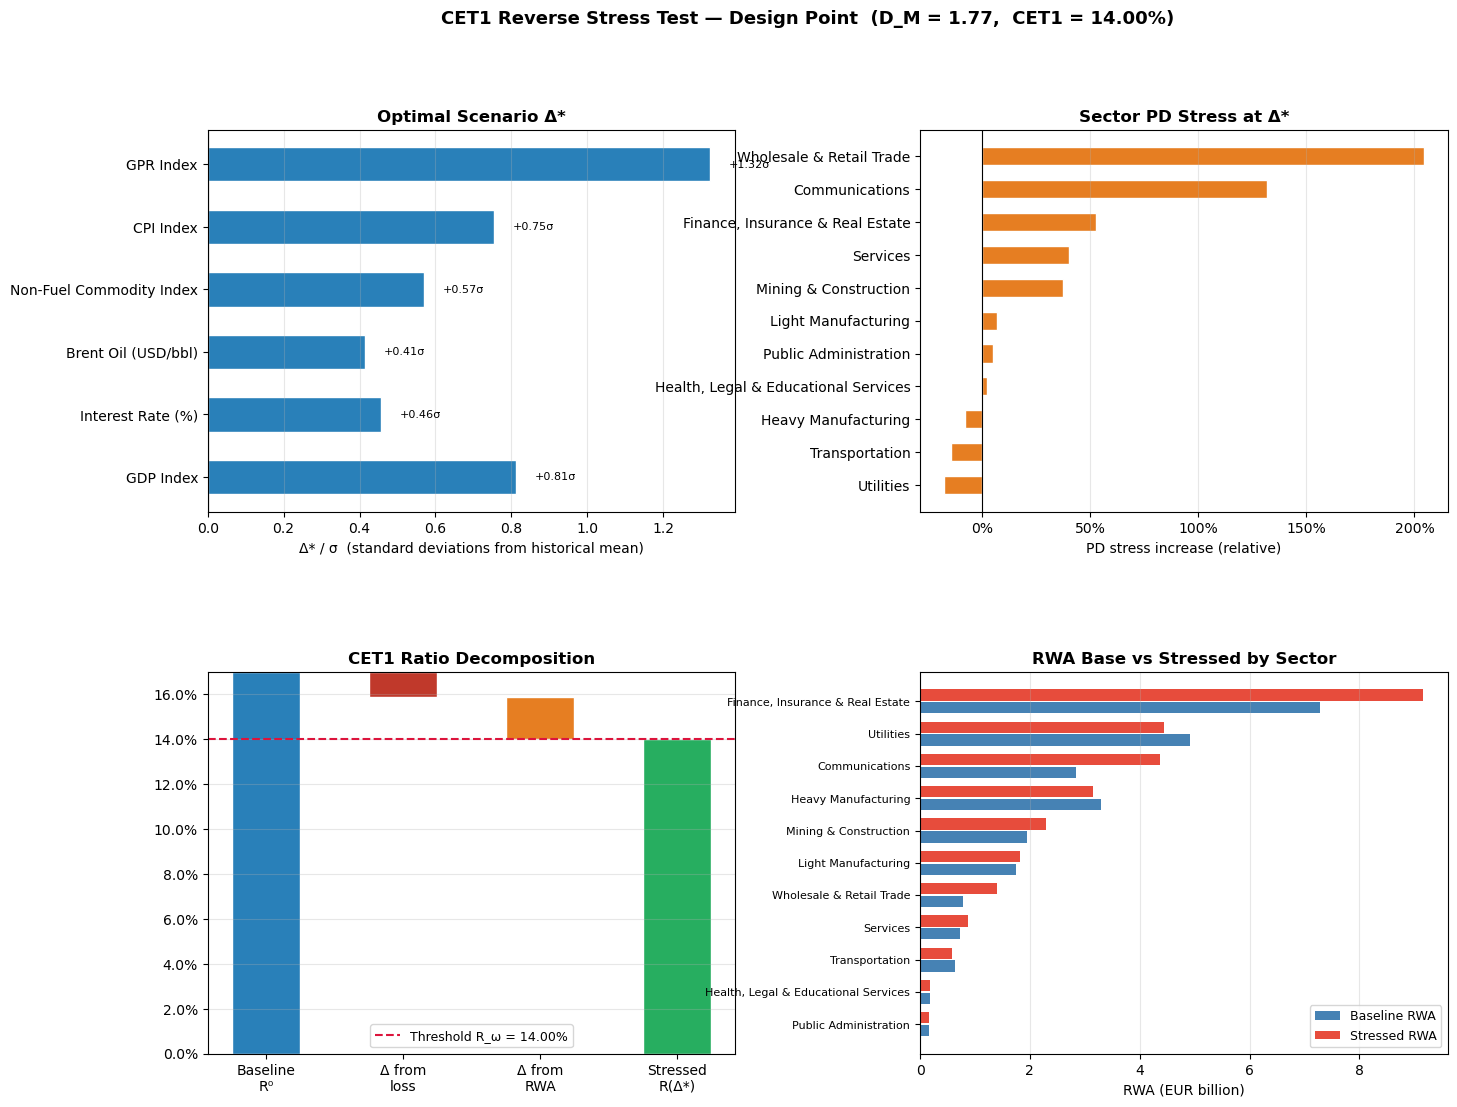

Chart saved → cet1_opt_results.png


In [12]:
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.35)

# ── A: Scenario deviations (bar chart, \u03c3 units) ───────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
colors_a = ['#c0392b' if d < 0 else '#2980b9' for d in deviations_sigma]
bars = ax_a.barh([VAR_LABELS[v] for v in ALL_VARS], deviations_sigma,
                 color=colors_a, edgecolor='white', height=0.55)
ax_a.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, deviations_sigma):
    ax_a.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
              f'{val:+.2f}\u03c3', va='center',
              ha='left' if val >= 0 else 'right', fontsize=8)
ax_a.set_xlabel('\u0394* / \u03c3  (standard deviations from historical mean)')
ax_a.set_title('Optimal Scenario \u0394*', fontweight='bold')
ax_a.grid(axis='x', alpha=0.3)

# ── B: Sector PD stress multiplier ────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
sector_mult = df_valid.groupby('sector')['pd_mult'].mean().sort_values(ascending=True)
ax_b.barh(sector_mult.index, sector_mult.values - 1,
          color='#e67e22', edgecolor='white', height=0.55)
ax_b.axvline(0, color='black', lw=0.8)
ax_b.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax_b.set_xlabel('PD stress increase (relative)')
ax_b.set_title('Sector PD Stress at \u0394*', fontweight='bold')
ax_b.grid(axis='x', alpha=0.3)

# ── C: CET1 ratio decomposition waterfall ─────────────────────────────────────
# R(Δ) = (CET1_0 - (L(Δ)-L_base)) / RWA(Δ)  where incremental loss = L(Δ)-L_base
# Decompose: R0  →  effect of incremental loss at constant RWA_total_0  →  RWA shift
ax_c = fig.add_subplot(gs[1, 0])
incr_loss_opt   = L_opt - loss_base
delta_loss_cet1 = -incr_loss_opt / RWA_total_0                                # loss effect
r_after_loss    = CET1_RATIO_0 + delta_loss_cet1
delta_rwa_cet1  = (CET1_0 - incr_loss_opt) / RWA_opt - (CET1_0 - incr_loss_opt) / RWA_total_0
waterfall_vals  = [CET1_RATIO_0, delta_loss_cet1, delta_rwa_cet1, R_opt]
waterfall_lbls  = ['Baseline\nR⁰', 'Δ from\nloss', 'Δ from\nRWA', 'Stressed\nR(Δ*)']
bottoms = [0, CET1_RATIO_0, r_after_loss, 0]
bar_colors = ['#2980b9', '#c0392b', '#e67e22', '#27ae60']
ax_c.bar(waterfall_lbls, waterfall_vals, bottom=bottoms, color=bar_colors,
         edgecolor='white', width=0.5)
ax_c.axhline(R_OMEGA, color='crimson', ls='--', lw=1.5,
             label=f'Threshold R_ω = {R_OMEGA:.2%}')
ax_c.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax_c.set_title('CET1 Ratio Decomposition', fontweight='bold')
ax_c.legend(fontsize=9)
ax_c.grid(axis='y', alpha=0.3)

# ── D: RWA base vs stressed by sector ─────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
rwa_by_sector = df_valid.groupby('sector')[['rwa_base', 'rwa_stressed']].sum() / 1000
rwa_by_sector = rwa_by_sector.sort_values('rwa_stressed', ascending=True)
y_pos = np.arange(len(rwa_by_sector))
ax_d.barh(y_pos - 0.2, rwa_by_sector['rwa_base'], height=0.35,
          color='steelblue', label='Baseline RWA')
ax_d.barh(y_pos + 0.2, rwa_by_sector['rwa_stressed'], height=0.35,
          color='#e74c3c', label='Stressed RWA')
ax_d.set_yticks(y_pos)
ax_d.set_yticklabels(rwa_by_sector.index, fontsize=8)
ax_d.set_xlabel('RWA (EUR billion)')
ax_d.set_title('RWA Base vs Stressed by Sector', fontweight='bold')
ax_d.legend(fontsize=9)
ax_d.grid(axis='x', alpha=0.3)

fig.suptitle(f'CET1 Reverse Stress Test — Design Point  '
             f'(D_M = {D_opt:.2f},  CET1 = {R_opt:.2%})',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('opt_lasso_opt_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved \u2192 opt_lasso_opt_results.png')

## 11. Pareto Frontier — Plausibility vs. CET1 Depletion

Sweep the breakdown threshold from a mild depletion to a severe one,
and plot the minimum Mahalanobis distance required at each level.
This is the CET1-ratio analogue of the loss frontier in notebook 04.

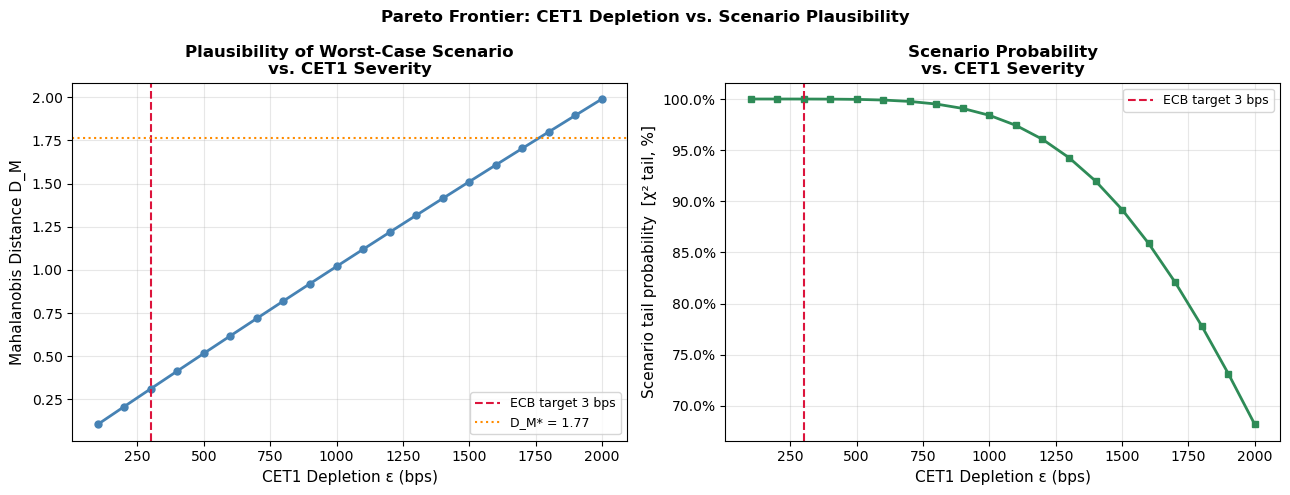

Chart saved → cet1_opt_frontier.png


In [13]:
# Sweep ε from 1% to 20% depletion  (R_ω = R⁰ × (1 − ε))
depletions  = np.arange(0.01, 0.201, 0.01)
thresholds  = CET1_RATIO_0 * (1 - depletions)
front_D     = []
front_R     = []
front_ok    = []
delta_warm  = np.zeros(N_VARS)

for thr in thresholds:
    def _con(d, t=thr):
        return t - cet1_ratio(d)
    def _con_jac(d, t=thr):
        return approx_fprime(d, lambda dd: t - cet1_ratio(dd), 1e-6)
    res = minimize(mahal_sq, delta_warm, method='SLSQP',
                   jac=mahal_sq_grad,
                   constraints={'type': 'ineq', 'fun': _con, 'jac': _con_jac},
                   options=dict(maxiter=2000, ftol=1e-10))
    R   = cet1_ratio(res.x)
    D   = np.sqrt(mahal_sq(res.x))
    ok  = R <= thr + 1e-3
    front_D.append(D if ok else np.nan)
    front_R.append(R if ok else np.nan)
    front_ok.append(ok)
    if ok:
        delta_warm = res.x.copy()

dep_ok = depletions[front_ok]
D_ok   = np.array(front_D)[front_ok]
p_ok   = chi2.sf(D_ok**2, df=N_VARS) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(dep_ok * 100, D_ok, 'o-', color='steelblue', lw=2, ms=5)
ax1.axvline(DEPLETION * 100, color='crimson', ls='--', lw=1.5,
            label=f'ECB target {DEPLETION*100:.0f} bps')
ax1.axhline(D_opt, color='darkorange', ls=':', lw=1.5,
            label=f'D_M* = {D_opt:.2f}')
ax1.set_xlabel('CET1 Depletion \u03b5 (bps)', fontsize=11)
ax1.set_ylabel('Mahalanobis Distance D_M', fontsize=11)
ax1.set_title('Plausibility of Worst-Case Scenario\nvs. CET1 Severity', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:.0f}'))

ax2.plot(dep_ok * 100, p_ok, 's-', color='seagreen', lw=2, ms=5)
ax2.axvline(DEPLETION * 100, color='crimson', ls='--', lw=1.5,
            label=f'ECB target {DEPLETION*100:.0f} bps')
ax2.set_xlabel('CET1 Depletion \u03b5 (bps)', fontsize=11)
ax2.set_ylabel('Scenario tail probability  [\u03c7\u00b2 tail, %]', fontsize=11)
ax2.set_title('Scenario Probability\nvs. CET1 Severity', fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:.0f}'))

fig.suptitle('Pareto Frontier: CET1 Depletion vs. Scenario Plausibility',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('opt_lasso_opt_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved \u2192 opt_lasso_opt_frontier.png')

## 12. Hurlin et al. Figures 1 & 2 — CET1 Frontier Geometry

2-D projections onto the two most impactful scenario dimensions, showing:
- **Fig. 1 analog**: CET1 breach region, plausibility contours, local neighbourhood $\mathcal{S}_\rho$
- **Fig. 2 analog**: Near-optimal set $\mathcal{N}_\varepsilon$

The CET1-ratio breakdown frontier replaces the loss frontier of notebook 04.

Shocks on the **non-displayed** dimensions are held at the optimal **6-D** design point $\Delta^*$ (`delta_opt`), not at zero.


2-D slice:  x = GPR Index  |Δ/σ| = 1.32
            y = GDP Index  |Δ/σ| = 0.81

  Projection of 6-D optimum: GPR Index = +1.32σ, GDP Index = +0.81σ
  D_M = 1.766,  CET1 at full Δ* = 14.0000%


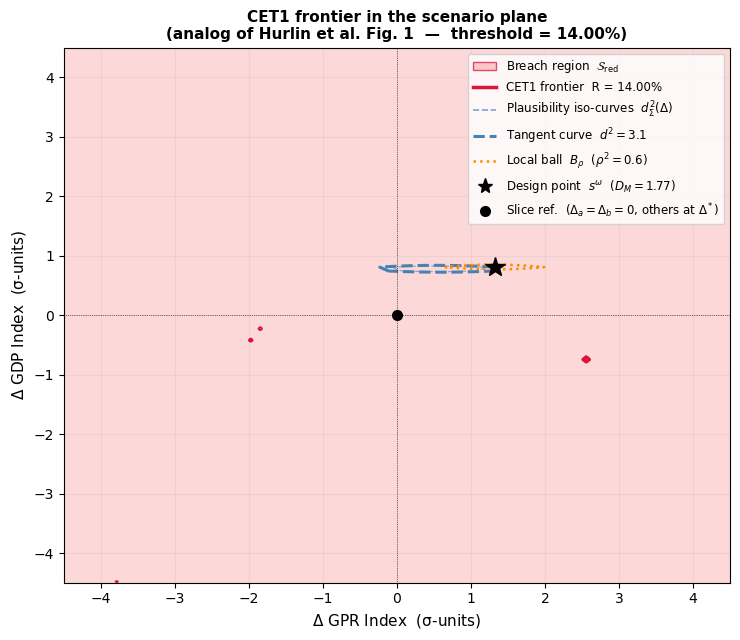

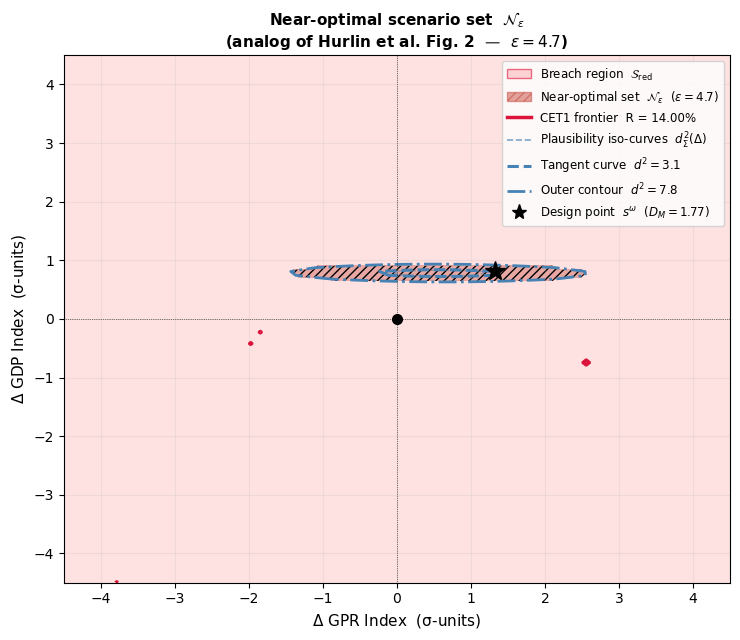

Figures saved  →  cet1_hurlin_fig1_analog.png,  cet1_hurlin_fig2_analog.png


In [14]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Variable selection: two most impactful dimensions at the 6-D design point ─
top2  = np.argsort(np.abs(deviations_sigma))[-2:][::-1]
idx_a = int(top2[0])
idx_b = int(top2[1])
lbl_a = VAR_LABELS[ALL_VARS[idx_a]]
lbl_b = VAR_LABELS[ALL_VARS[idx_b]]
print(f'2-D slice:  x = {lbl_a}  |\u0394/\u03c3| = {abs(deviations_sigma[idx_a]):.2f}')
print(f'            y = {lbl_b}  |\u0394/\u03c3| = {abs(deviations_sigma[idx_b]):.2f}')

# ── 2-D grid ─────────────────────────────────────────────────────────────────
N_G   = 140
rng_a = 4.5 * stds[idx_a];  rng_b = 4.5 * stds[idx_b]
ga    = np.linspace(-rng_a, rng_a, N_G)
gb    = np.linspace(-rng_b, rng_b, N_G)
GA, GB = np.meshgrid(ga, gb)

# 2-D slice through the design point Δ*: only (idx_a, idx_b) sweep the grid; every
# other coordinate stays at delta_opt (parallel slice in Δ-space; not fixing others at 0).
npts    = N_G * N_G
d_shock = np.broadcast_to(delta_opt, (npts, N_VARS)).copy()
d_shock[:, idx_a] = GA.ravel()
d_shock[:, idx_b] = GB.ravel()
adj_f = np.clip(logit_pd0[None, :] + d_shock @ B_total.T, -50, 50)
pd_f  = np.clip(1 / (1 + np.exp(-adj_f)), 1e-9, 1 - 1e-9)
# Loss on grid
cp_f  = norm.cdf((norm.ppf(pd_f) + sqrt_rho[None, :] * inv_q) / sqrt_1mrho[None, :])
L_2D  = (ead[None, :] * LGD * cp_f).sum(1).reshape(N_G, N_G)
# RWA on grid
K_f   = calculate_capital_requirement(pd_f, LGD, rho[None, :], maturity=MATURITY)
RWA_2D = (ead[None, :] * K_f * 12.5).sum(1).reshape(N_G, N_G) + RWA_other
# CET1 on grid — same as cet1_ratio(): incremental corporate loss, full bank RWA
R_2D  = (CET1_0 - (L_2D - loss_base)) / RWA_2D

# Mahalanobis d²(Δ) from baseline Δ=0 (full shock vector at each grid point)
D2_2D = ((d_shock @ Sigma_inv) * d_shock).sum(1).reshape(N_G, N_G)

# ── 6-D design point projected onto this plane (global optimum Δ*) ─
ab_star  = delta_opt[[idx_a, idx_b]]
d2_star  = mahal_sq(delta_opt)
dm_star  = np.sqrt(d2_star)
r_star   = cet1_ratio(delta_opt)
print(f'\n  Projection of 6-D optimum: {lbl_a} = {ab_star[0]/stds[idx_a]:+.2f}σ, '
      f'{lbl_b} = {ab_star[1]/stds[idx_b]:+.2f}σ')
print(f'  D_M = {dm_star:.3f},  CET1 at full Δ* = {r_star:.4%}')


# Mahalanobis centred at design point (local neighbourhood ball)
dfl2           = np.zeros((N_G * N_G, N_VARS))
dfl2[:, idx_a] = GA.ravel() - ab_star[0];  dfl2[:, idx_b] = GB.ravel() - ab_star[1]
D2_dpt         = ((dfl2 @ Sigma_inv) * dfl2).sum(1).reshape(N_G, N_G)

rho_ball = d2_star * 0.20
epsilon  = d2_star * 1.50
near_opt = (R_2D <= R_OMEGA) & (D2_2D <= d2_star + epsilon)

gx = GA / stds[idx_a];  gy = GB / stds[idx_b]
axs = ab_star[0] / stds[idx_a];  ays = ab_star[1] / stds[idx_b]
inner_levs_raw = np.array([0.20, 0.45, 0.70, 0.90]) * d2_star
inner_levs = inner_levs_raw[inner_levs_raw > 0]   # drop zero levels to avoid contour error

# ── Figure 1 analog ──────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7.5, 6.5))

ax1.contourf(gx, gy, R_2D, levels=[R_2D.min(), R_OMEGA],
             colors=['#fdb8b8'], alpha=0.55)
ax1.contour(gx, gy, R_2D, levels=[R_OMEGA],
            colors=['crimson'], linewidths=2.5)
if len(inner_levs) > 0:
    ax1.contour(gx, gy, D2_2D, levels=inner_levs,
                colors='steelblue', linewidths=0.9, linestyles='--', alpha=0.55)
ax1.contour(gx, gy, D2_2D, levels=[d2_star],
            colors='steelblue', linewidths=2.2, linestyles='--')
ax1.contour(gx, gy, D2_dpt, levels=[rho_ball],
            colors='darkorange', linewidths=1.8, linestyles=':')
ax1.plot(axs, ays, 'k*', ms=15, zorder=6)
ax1.plot(0,   0,   'ko', ms=7,  zorder=5)
ax1.axhline(0, color='k', lw=0.5, ls=':')
ax1.axvline(0, color='k', lw=0.5, ls=':')

ax1.legend(handles=[
    Patch(fc='#fdb8b8', ec='crimson', alpha=0.75,
          label='Breach region  $\\mathcal{S}_{\\mathrm{red}}$'),
    Line2D([0],[0], color='crimson', lw=2.5,
           label=f'CET1 frontier  R = {R_OMEGA*100:.2f}%'),
    Line2D([0],[0], color='steelblue', lw=1.2, ls='--', alpha=0.7,
           label='Plausibility iso-curves  $d^2_\\Sigma(\\Delta)$'),
    Line2D([0],[0], color='steelblue', lw=2.2, ls='--',
           label=f'Tangent curve  $d^2 = {d2_star:.1f}$'),
    Line2D([0],[0], color='darkorange', lw=1.8, ls=':',
           label=f'Local ball  $B_\\rho$  ($\\rho^2 = {rho_ball:.1f}$)'),
    Line2D([0],[0], marker='*', color='k', ms=11, ls='',
           label=f'Design point  $s^\\omega$  ($D_M = {dm_star:.2f}$)'),
    Line2D([0],[0], marker='o', color='k', ms=7, ls='',
           label='Slice ref.  ($\\Delta_a=\\Delta_b=0$, others at $\\Delta^*$)'),
], fontsize=8.5, loc='best')

ax1.set_xlabel(f'$\\Delta$ {lbl_a}  (\u03c3-units)', fontsize=11)
ax1.set_ylabel(f'$\\Delta$ {lbl_b}  (\u03c3-units)', fontsize=11)
ax1.set_title(
    'CET1 frontier in the scenario plane\n'
    f'(analog of Hurlin et al. Fig. 1  \u2014  threshold = {R_OMEGA:.2%})',
    fontsize=11, fontweight='bold')
ax1.set_xlim(gx.min(), gx.max());  ax1.set_ylim(gy.min(), gy.max())
ax1.grid(alpha=0.2)
fig1.tight_layout()
plt.savefig('opt_lasso_hurlin_fig1_analog.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2 analog ──────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7.5, 6.5))

ax2.contourf(gx, gy, R_2D, levels=[R_2D.min(), R_OMEGA],
             colors=['#fdb8b8'], alpha=0.40)
ax2.contourf(gx, gy, near_opt.astype(float), levels=[0.5, 1.5],
             colors=['#c0392b'], alpha=0.35, hatches=['////'])
ax2.contour(gx, gy, R_2D, levels=[R_OMEGA],
            colors=['crimson'], linewidths=2.5)
if len(inner_levs) > 0:
    ax2.contour(gx, gy, D2_2D, levels=inner_levs,
                colors='steelblue', linewidths=0.9, linestyles='--', alpha=0.55)
ax2.contour(gx, gy, D2_2D, levels=[d2_star],
            colors='steelblue', linewidths=2.2, linestyles='--')
ax2.contour(gx, gy, D2_2D, levels=[d2_star + epsilon],
            colors='steelblue', linewidths=2.0, linestyles='-.')
ax2.plot(axs, ays, 'k*', ms=15, zorder=6)
ax2.plot(0,   0,   'ko', ms=7,  zorder=5)
ax2.axhline(0, color='k', lw=0.5, ls=':')
ax2.axvline(0, color='k', lw=0.5, ls=':')

ax2.legend(handles=[
    Patch(fc='#fdb8b8', ec='crimson', alpha=0.60,
          label='Breach region  $\\mathcal{S}_{\\mathrm{red}}$'),
    Patch(fc='#c0392b', ec='#c0392b', alpha=0.45, hatch='////',
          label=f'Near-optimal set  $\\mathcal{{N}}_\\varepsilon$  ($\\varepsilon = {epsilon:.1f}$)'),
    Line2D([0],[0], color='crimson', lw=2.5,
           label=f'CET1 frontier  R = {R_OMEGA*100:.2f}%'),
    Line2D([0],[0], color='steelblue', lw=1.2, ls='--', alpha=0.7,
           label='Plausibility iso-curves  $d^2_\\Sigma(\\Delta)$'),
    Line2D([0],[0], color='steelblue', lw=2.2, ls='--',
           label=f'Tangent curve  $d^2 = {d2_star:.1f}$'),
    Line2D([0],[0], color='steelblue', lw=2.0, ls='-.',
           label=f'Outer contour  $d^2 = {d2_star+epsilon:.1f}$'),
    Line2D([0],[0], marker='*', color='k', ms=11, ls='',
           label=f'Design point  $s^\\omega$  ($D_M = {dm_star:.2f}$)'),
], fontsize=8.5, loc='best')

ax2.set_xlabel(f'$\\Delta$ {lbl_a}  (\u03c3-units)', fontsize=11)
ax2.set_ylabel(f'$\\Delta$ {lbl_b}  (\u03c3-units)', fontsize=11)
ax2.set_title(
    'Near-optimal scenario set  $\\mathcal{N}_\\varepsilon$\n'
    f'(analog of Hurlin et al. Fig. 2  \u2014  $\\varepsilon = {epsilon:.1f}$)',
    fontsize=11, fontweight='bold')
ax2.set_xlim(gx.min(), gx.max());  ax2.set_ylim(gy.min(), gy.max())
ax2.grid(alpha=0.2)
fig2.tight_layout()
plt.savefig('opt_lasso_hurlin_fig2_analog.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figures saved  \u2192  opt_lasso_hurlin_fig1_analog.png,  opt_lasso_hurlin_fig2_analog.png')

Each panel conditions on the **other four shocks at** $\Delta^*$ (`delta_opt`).

## 13. Frontier Geometry — All Factor Pairings

The Fig. 1-style plot (breach region + plausibility iso-curves + **6-D design point** projected onto each factor plane) for every pair of the 6 macro variables. The star marks $(\Delta^*_i,\Delta^*_j)$ from the global optimum `delta_opt`; tangent plausibility levels use $D_M^2 = \Delta^{*\top}\Sigma^{-1}\Delta^*$ (not a separate 2-D constrained optimum per panel).


  Pair  1/15  (GDP_Growth vs Interest_Rate)  done
  Pair  2/15  (GDP_Growth vs Brent_Oil)  done
  Pair  3/15  (GDP_Growth vs Fuel_Index)  done
  Pair  4/15  (GDP_Growth vs CPI)  done
  Pair  5/15  (GDP_Growth vs GPR_Global)  done
  Pair  6/15  (Interest_Rate vs Brent_Oil)  done
  Pair  7/15  (Interest_Rate vs Fuel_Index)  done
  Pair  8/15  (Interest_Rate vs CPI)  done
  Pair  9/15  (Interest_Rate vs GPR_Global)  done
  Pair 10/15  (Brent_Oil vs Fuel_Index)  done
  Pair 11/15  (Brent_Oil vs CPI)  done
  Pair 12/15  (Brent_Oil vs GPR_Global)  done
  Pair 13/15  (Fuel_Index vs CPI)  done
  Pair 14/15  (Fuel_Index vs GPR_Global)  done
  Pair 15/15  (CPI vs GPR_Global)  done


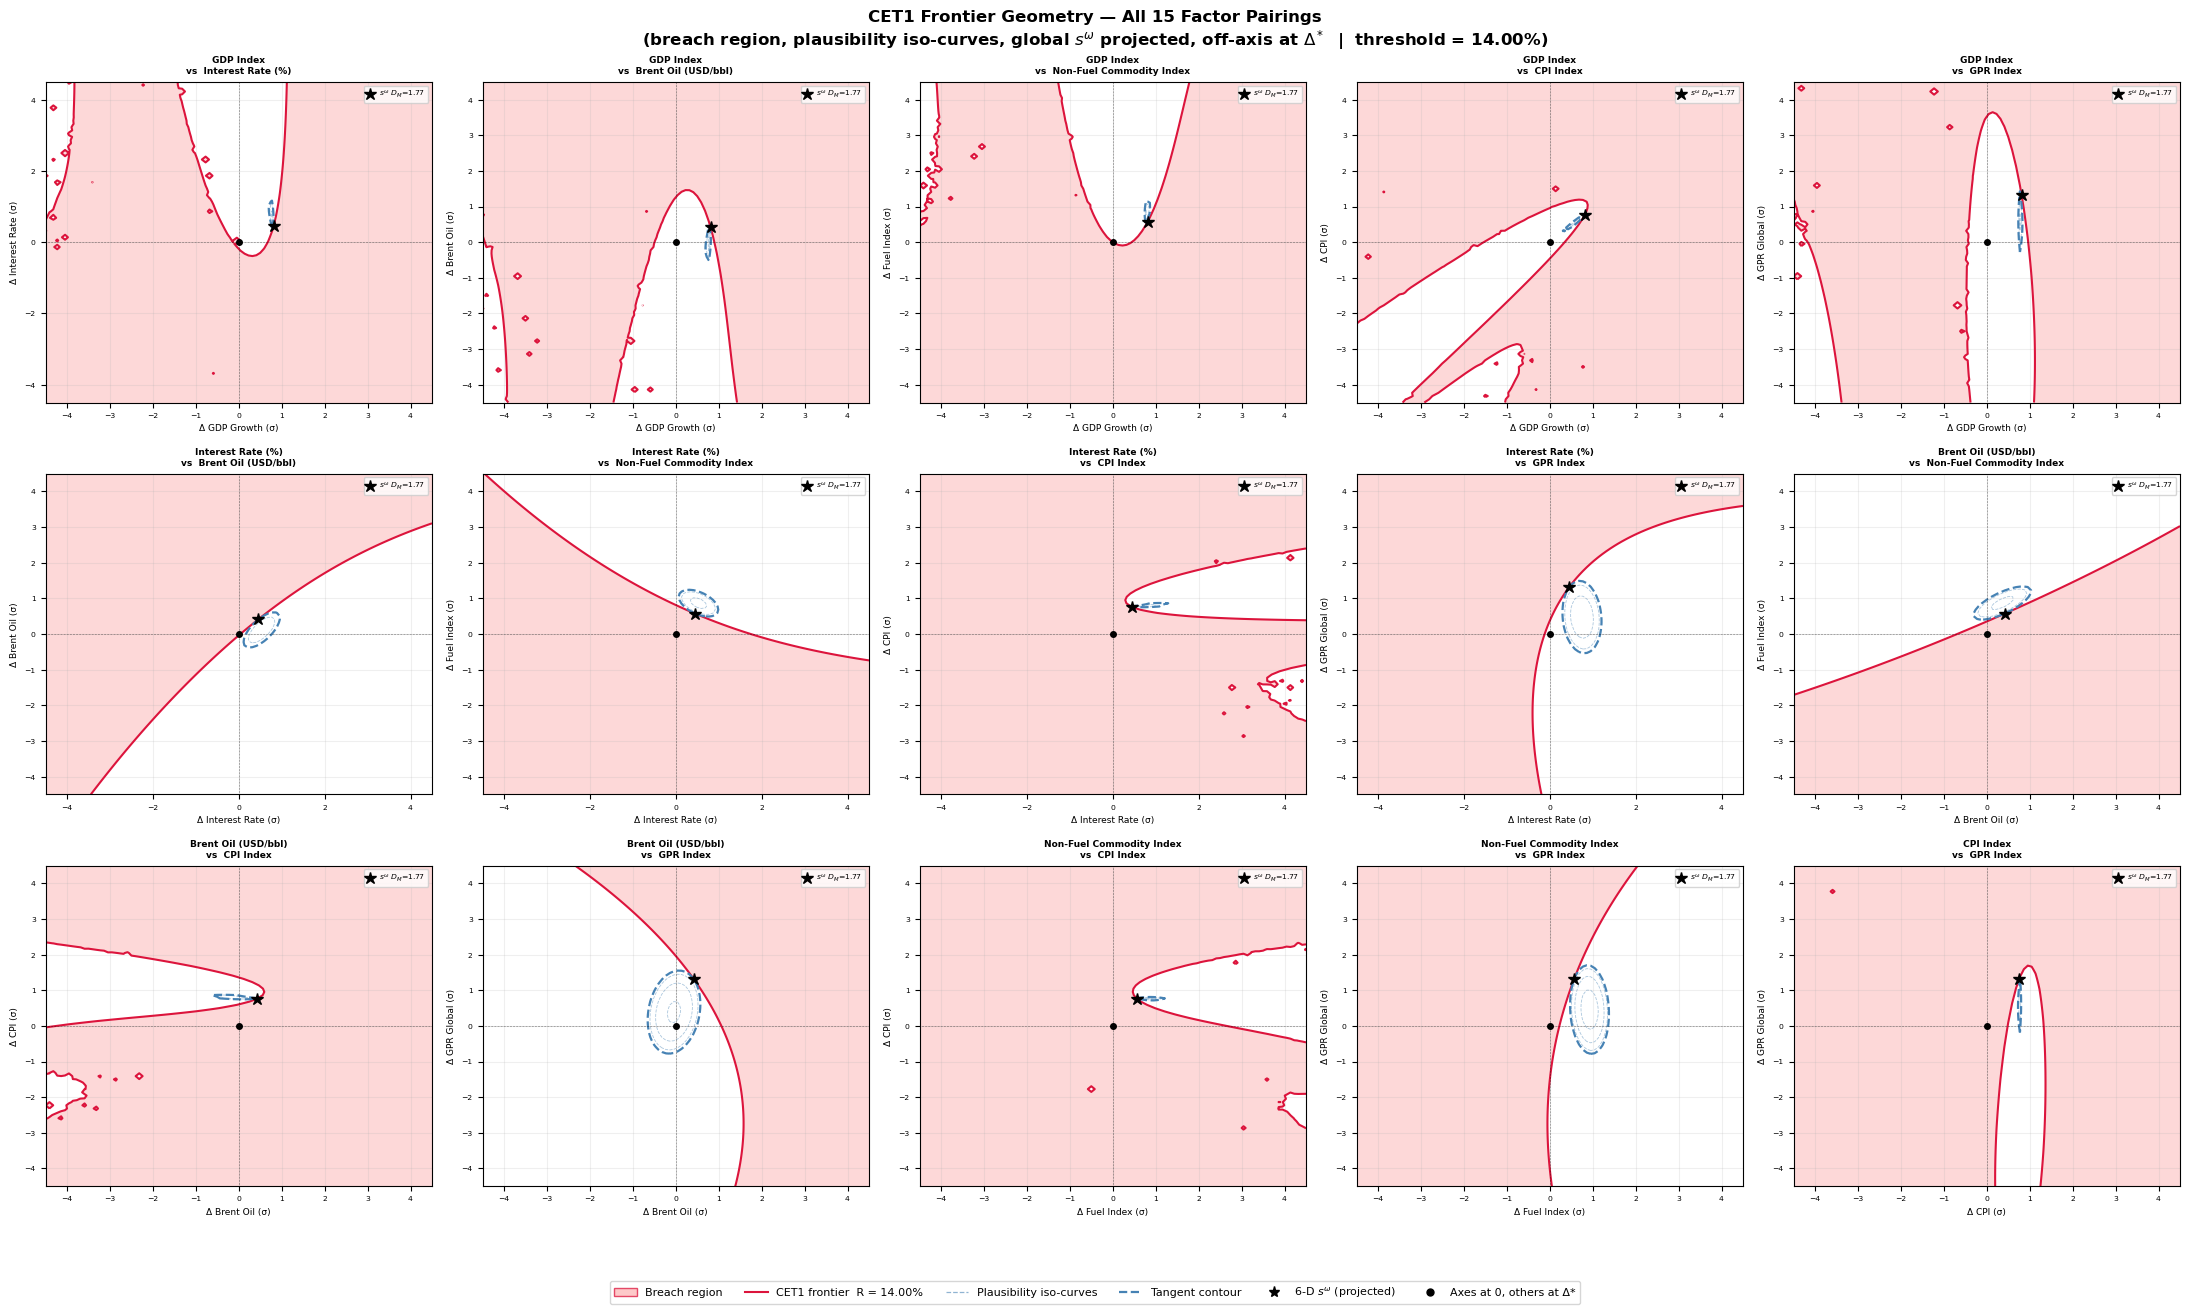

Chart saved → cet1_frontier_all_pairs.png


In [15]:
from itertools import combinations
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

N_G_ALL = 100   # grid resolution per panel (lower than single-panel for speed)

all_pairs = list(combinations(range(N_VARS), 2))   # 15 pairs

fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes_flat = axes.flatten()

d2_global = mahal_sq(delta_opt)
dm_global = np.sqrt(d2_global)

for plot_idx, (ia, ib) in enumerate(all_pairs):
    ax    = axes_flat[plot_idx]
    lbl_a = VAR_LABELS[ALL_VARS[ia]]
    lbl_b = VAR_LABELS[ALL_VARS[ib]]

    # ── 2-D grid in raw units ───────────────────────────────────────────────
    ga = np.linspace(-4.5 * stds[ia], 4.5 * stds[ia], N_G_ALL)
    gb = np.linspace(-4.5 * stds[ib], 4.5 * stds[ib], N_G_ALL)
    GA, GB = np.meshgrid(ga, gb)

    # Full shock: vary (ia, ib) on grid; other components fixed at Δ*
    npts    = N_G_ALL * N_G_ALL
    d_shock = np.broadcast_to(delta_opt, (npts, N_VARS)).copy()
    d_shock[:, ia] = GA.ravel()
    d_shock[:, ib] = GB.ravel()

    adj_f = np.clip(logit_pd0[None, :] + d_shock @ B_total.T, -50, 50)
    pd_f  = np.clip(1 / (1 + np.exp(-adj_f)), 1e-9, 1 - 1e-9)

    # Gordy loss on grid
    cp_f  = norm.cdf((norm.ppf(pd_f) + sqrt_rho[None, :] * inv_q) / sqrt_1mrho[None, :])
    L_2D  = (ead[None, :] * LGD * cp_f).sum(1).reshape(N_G_ALL, N_G_ALL)

    # Stressed RWA on grid (corporate + constant non-corporate)
    K_f    = calculate_capital_requirement(pd_f, LGD, rho[None, :], maturity=MATURITY)
    RWA_2D = (ead[None, :] * K_f * 12.5).sum(1).reshape(N_G_ALL, N_G_ALL) + RWA_other

    # CET1 ratio on grid (incremental loss depletion)
    R_2D = (CET1_0 - (L_2D - loss_base)) / RWA_2D

    # Mahalanobis d² from baseline (full Δ at each grid point)
    D2_2D = ((d_shock @ Sigma_inv) * d_shock).sum(1).reshape(N_G_ALL, N_G_ALL)

    # ── σ-unit axes for plotting ────────────────────────────────────────────
    gx = GA / stds[ia]
    gy = GB / stds[ib]

    # Breach region + frontier
    breach_exists = np.any(R_2D <= R_OMEGA)
    if breach_exists:
        ax.contourf(gx, gy, R_2D, levels=[R_2D.min(), R_OMEGA],
                    colors=['#fdb8b8'], alpha=0.55)
        ax.contour(gx, gy, R_2D, levels=[R_OMEGA],
                   colors=['crimson'], linewidths=1.5)

    # Plausibility iso-curves + tangent contour (levels from full Δ*; off-axis at Δ*)
    inner_levs = np.array([0.20, 0.45, 0.70, 0.90]) * d2_global
    inner_levs = inner_levs[inner_levs > 0]
    if len(inner_levs) > 0:
        ax.contour(gx, gy, D2_2D, levels=inner_levs,
                   colors='steelblue', linewidths=0.6, linestyles='--', alpha=0.45)
    ax.contour(gx, gy, D2_2D, levels=[d2_global],
               colors='steelblue', linewidths=1.6, linestyles='--')

    # Design point = projection of global Δ* onto this (i,j) plane
    axs = delta_opt[ia] / stds[ia]
    ays = delta_opt[ib] / stds[ib]
    ax.plot(axs, ays, 'k*', ms=9, zorder=6,
            label=f'$s^\\omega$ $D_M$={dm_global:.2f}')
    ax.legend(fontsize=5.5, loc='upper right', handlelength=0.8)

    # Baseline and axes
    ax.plot(0, 0, 'ko', ms=4, zorder=5)
    ax.axhline(0, color='k', lw=0.4, ls=':')
    ax.axvline(0, color='k', lw=0.4, ls=':')

    # Short labels — strip underscores for readability
    short_a = ALL_VARS[ia].replace('_', ' ')
    short_b = ALL_VARS[ib].replace('_', ' ')
    ax.set_xlabel(f'Δ {short_a} (σ)', fontsize=6.5)
    ax.set_ylabel(f'Δ {short_b} (σ)', fontsize=6.5)
    ax.set_title(f'{lbl_a}\nvs  {lbl_b}', fontsize=6.5, fontweight='bold')
    ax.tick_params(labelsize=5.5)
    ax.set_xlim(gx.min(), gx.max())
    ax.set_ylim(gy.min(), gy.max())
    ax.grid(alpha=0.2)
    print(f'  Pair {plot_idx+1:2d}/15  ({ALL_VARS[ia]} vs {ALL_VARS[ib]})  done')

# Shared legend below the grid
legend_elements = [
    Patch(fc='#fdb8b8', ec='crimson', alpha=0.75, label='Breach region'),
    Line2D([0],[0], color='crimson', lw=1.5, label=f'CET1 frontier  R = {R_OMEGA*100:.2f}%'),
    Line2D([0],[0], color='steelblue', lw=0.9, ls='--', alpha=0.6,
           label='Plausibility iso-curves'),
    Line2D([0],[0], color='steelblue', lw=1.6, ls='--', label='Tangent contour'),
    Line2D([0],[0], marker='*', color='k', ms=8, ls='', label='6-D $s^\\omega$ (projected)'),
    Line2D([0],[0], marker='o', color='k', ms=5, ls='', label='Axes at 0, others at Δ*'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=8,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

fig.suptitle(
    f'CET1 Frontier Geometry — All 15 Factor Pairings\n'
    f'(breach region, plausibility iso-curves, global $s^\\omega$ projected, off-axis at $\\Delta^*$  |  threshold = {R_OMEGA*100:.2f}%)',
    fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('opt_lasso_frontier_all_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → opt_lasso_frontier_all_pairs.png')


## Summary

| | |
|---|---|
| **Initial CET1 ratio** $R^0$ | 14.00% |
| **Depletion threshold** $\varepsilon$ | 300 bps |
| **Breakdown threshold** $R^\omega = R^0 - \varepsilon$ | 11.00% |
| **Optimal Mahalanobis distance** $D_M^*$ | see cell 8 |
| **Scenario probability** ($\chi^2(6)$ tail) | see cell 8 |
| **Gordy quantile** | 99.9% |
| **LGD** | 40% |
| **Maturity** | 2.5 years |